# Stage 2 analysis from flow logs

Parse all `flow_stage2_*.log` files in `benchmark_logs/text_gpt-4.1.-mini_graph/` to get a unified view of QA runs. Logs can be from multiple runs/resumes (different timestamps, "Resuming: N already done"), so we:
- Parse each log and compute **global QA index** = offset + local_qa_index (offset from "Resuming: N already done", 0 if absent).
- Merge all records; when the same global index appears in multiple logs (e.g. retries or overlapping runs), we keep the **latest by timestamp** so each question has one canonical record.

In [21]:
import re
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np

LOG_DIR = Path("benchmark_logs/multi_gpt-4.1-mini_graph_2try")
assert LOG_DIR.is_dir(), f"Not a directory: {LOG_DIR}"

def find_stage2_logs():
    """All flow_stage2_*.log in the directory, sorted by name (chronological)."""
    logs = sorted(LOG_DIR.glob("flow_stage2_*.log"))
    return [f for f in logs if f.is_file()]

log_files = find_stage2_logs()
print(f"Found {len(log_files)} log files")
for f in log_files:
    print(f"  {f.name}")

Found 6 log files
  flow_stage2_RUN-1_20260310_063441.log
  flow_stage2_RUN-2_20260310_063452.log
  flow_stage2_RUN-3_20260310_211756.log
  flow_stage2_RUN-3_20260310_222021.log
  flow_stage2_RUN-3_20260310_222044.log
  flow_stage2_RUN-3_20260310_230543.log


## Parsing one log file

Each QA block in a log has 4 lines:
1. `[timestamp] QA K/5000 (user_id=X, row=Y) | search starting`
2. `[timestamp] QA K/5000 | search done (N results, X.Xs)`
3. `[timestamp] QA K/5000 | answer LLM starting`
4. `[timestamp] QA K/5000 | answer LLM done (X.Xs)`

If the log has "Resuming: M already done", then global_qa_index = M + K for that block.

In [22]:
TIMESTAMP_RE = re.compile(r"^\[(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})\]")
RESUMING_RE = re.compile(r"Resuming: (\d+) already done")
QA_START_RE = re.compile(r"QA (\d+)/\d+ \(user_id=(\d+), row=(\d+)\) \| search starting")
QA_START_CONTINUE_RE = re.compile(r"QA (\d+)/\d+ \| search starting")
SEARCH_DONE_RE = re.compile(r"QA (\d+)/\d+ \| search done \((\d+) results, ([\d.]+)s\)")
LLM_DONE_RE = re.compile(r"QA (\d+)/\d+ \| answer LLM done \(([\d.]+)s\)")

def parse_log(path: Path):
    """Parse a single flow_stage2 log. Returns list of dicts (one per completed QA)."""
    offset = 0
    run_start = None
    records = []
    current = None  # {local_qa, user_id, row, ts_start, ...}
    
    with open(path, "r") as f:
        for line in f:
            line = line.rstrip()
            if not line:
                continue
            ts_match = TIMESTAMP_RE.match(line)
            ts = ts_match.group(1) if ts_match else None
            
            if "Resuming:" in line:
                m = RESUMING_RE.search(line)
                if m:
                    offset = int(m.group(1))
                continue
            
            if "Stage 2 QA |" in line and run_start is None and ts:
                run_start = ts
                continue
            
            # QA K/5000 (user_id=X, row=Y) | search starting
            m = QA_START_RE.search(line)
            if m:
                current = {
                    "local_qa": int(m.group(1)),
                    "user_id": int(m.group(2)),
                    "row": int(m.group(3)),
                    "ts_search_start": ts,
                    "log_file": path.name,
                    "run_start": run_start,
                    "offset": offset,
                }
                continue
            
            # QA K/5000 | search done (N results, X.Xs)
            m = SEARCH_DONE_RE.search(line)
            if m and current is not None and int(m.group(1)) == current["local_qa"]:
                current["num_results"] = int(m.group(2))
                current["search_sec"] = float(m.group(3))
                current["ts_search_done"] = ts
                continue
            
            # QA K/5000 | answer LLM done (X.Xs)
            m = LLM_DONE_RE.search(line)
            if m and current is not None and int(m.group(1)) == current["local_qa"]:
                current["llm_sec"] = float(m.group(2))
                current["ts_llm_done"] = ts
                current["global_qa_index"] = offset + current["local_qa"]
                records.append(current)
                current = None
                continue
    
    return records

In [23]:
all_records = []
for path in log_files:
    recs = parse_log(path)
    for r in recs:
        r["log_path"] = str(path)
    all_records.extend(recs)
    if recs:
        print(f"{path.name}: {len(recs)} QA records (offset={recs[0].get('offset', 0)}, global range ~{recs[0]['global_qa_index']}-{recs[-1]['global_qa_index']})")

print(f"\nTotal raw records: {len(all_records)}")

flow_stage2_RUN-2_20260310_063452.log: 2171 QA records (offset=0, global range ~1-2180)
flow_stage2_RUN-3_20260310_211756.log: 681 QA records (offset=2180, global range ~2181-2861)
flow_stage2_RUN-3_20260310_222044.log: 448 QA records (offset=2861, global range ~2862-3309)
flow_stage2_RUN-3_20260310_230543.log: 1691 QA records (offset=3309, global range ~3310-5000)

Total raw records: 4991


## Quick answers (1–4)

Summary: total time, per-QA generation/search time, and QAs by number of retrieved memories.

In [36]:
# 1. Total time
ts_min = pd.to_datetime(df["ts_search_start"].min(), format="%Y-%m-%d %H:%M:%S", errors="coerce")
ts_max = pd.to_datetime(df["ts_llm_done"].max(), format="%Y-%m-%d %H:%M:%S", errors="coerce")
total_wall_sec = (ts_max - ts_min).total_seconds()
total_sum = df["search_sec"].sum() + df["llm_sec"].sum()
print("1. TOTAL TIME")
print(f"   Wall-clock (first start → last done): {total_wall_sec/3600:.2f} h ({total_wall_sec:.0f} s)")
print(f"   Sum of per-QA (search + LLM):       {total_sum/3600:.2f} h ({total_sum:.0f} s)")

# 2. Per QA: generation time (LLM)
print("\n2. PER QA: GENERATION TIME (LLM answer), seconds")
print(df["llm_sec"].describe().to_string())

# 3. Per QA: search time
print("\n3. PER QA: SEARCH TIME, seconds")
print(df["search_sec"].describe().to_string())

# 4. QAs by 0 vs 1+ memories
zero = (df["num_results"] == 0).sum()
more = (df["num_results"] > 0).sum()
print("\n4. QAs BY RETRIEVED MEMORIES")
print(f"   QAs with 0 memories:   {zero} ({100*zero/len(df):.1f}%)")
print(f"   QAs with 1+ memories:  {more} ({100*more/len(df):.1f}%)")
print(df["num_results"].value_counts().sort_index().to_string())

1. TOTAL TIME
   Wall-clock (first start → last done): 19.06 h (68623 s)
   Sum of per-QA (search + LLM):       15.02 h (54087 s)

2. PER QA: GENERATION TIME (LLM answer), seconds
count    4991.000000
mean        4.109637
std         6.113966
min         0.800000
25%         2.400000
50%         3.300000
75%         4.400000
max       131.500000

3. PER QA: SEARCH TIME, seconds
count    4991.000000
mean        6.727289
std        55.212170
min         0.500000
25%         1.200000
50%         1.700000
75%         2.600000
max      1382.300000

4. QAs BY RETRIEVED MEMORIES
   QAs with 0 memories:   894 (17.9%)
   QAs with 1+ memories:  4097 (82.1%)
num_results
0      894
1       26
7       31
10    4040


## Build unified table and deduplicate by global QA index

Same question (global_qa_index) can appear in multiple logs (e.g. run 1 did 1–500, run 2 resumed from 501 but we might have restarts). Keep **one row per global_qa_index**: take the row with the **latest** `ts_llm_done` so we use the most recent completion.

In [35]:
df_raw = pd.DataFrame(all_records)

if df_raw.empty:
    raise SystemExit("No records parsed. Check log format and LOG_DIR.")

# Parse timestamps for ordering
df_raw["ts_llm_done_dt"] = pd.to_datetime(df_raw["ts_llm_done"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
df_raw["ts_search_start_dt"] = pd.to_datetime(df_raw["ts_search_start"], format="%Y-%m-%d %H:%M:%S", errors="coerce")

# One row per global_qa_index: keep latest by ts_llm_done
df_raw = df_raw.sort_values("ts_llm_done_dt")
df = df_raw.drop_duplicates(subset=["global_qa_index"], keep="last").copy()
df = df.sort_values("global_qa_index").reset_index(drop=True)

print(f"Unique global_qa_index count: {df['global_qa_index'].nunique()}")
print(f"Expected (e.g. 5000): check num_qa_pairs in logs")
df.head(10)

Unique global_qa_index count: 4991
Expected (e.g. 5000): check num_qa_pairs in logs


,local_qa,user_id,row,ts_search_start,log_file,run_start,offset,num_results,search_sec,ts_search_done,llm_sec,ts_llm_done,global_qa_index,log_path,ts_llm_done_dt,ts_search_start_dt
0,1,10,0,2026-03-10 06:34:56,flow_stage2_RUN-2_20260310_063452.log,2026-03-10 06:34:52,0,7,8.3,2026-03-10 06:35:05,3.2,2026-03-10 06:35:08,1,benchmark_logs/multi_gpt-4.1-mini_graph_2try/f...,2026-03-10 06:35:08,2026-03-10 06:34:56
1,2,10,1,2026-03-10 06:35:08,flow_stage2_RUN-2_20260310_063452.log,2026-03-10 06:34:52,0,7,3.5,2026-03-10 06:35:11,7.6,2026-03-10 06:35:19,2,benchmark_logs/multi_gpt-4.1-mini_graph_2try/f...,2026-03-10 06:35:19,2026-03-10 06:35:08
2,3,10,2,2026-03-10 06:35:19,flow_stage2_RUN-2_20260310_063452.log,2026-03-10 06:34:52,0,7,1.8,2026-03-10 06:35:21,2.7,2026-03-10 06:35:24,3,benchmark_logs/multi_gpt-4.1-mini_graph_2try/f...,2026-03-10 06:35:24,2026-03-10 06:35:19
3,4,10,3,2026-03-10 06:35:24,flow_stage2_RUN-2_20260310_063452.log,2026-03-10 06:34:52,0,7,0.9,2026-03-10 06:35:24,5.2,2026-03-10 06:35:30,4,benchmark_logs/multi_gpt-4.1-mini_graph_2try/f...,2026-03-10 06:35:30,2026-03-10 06:35:24
4,5,10,4,2026-03-10 06:35:30,flow_stage2_RUN-2_20260310_063452.log,2026-03-10 06:34:52,0,7,3.2,2026-03-10 06:35:33,2.9,2026-03-10 06:35:36,5,benchmark_logs/multi_gpt-4.1-mini_graph_2try/f...,2026-03-10 06:35:36,2026-03-10 06:35:30
5,6,10,5,2026-03-10 06:35:36,flow_stage2_RUN-2_20260310_063452.log,2026-03-10 06:34:52,0,7,1.0,2026-03-10 06:35:37,4.3,2026-03-10 06:35:41,6,benchmark_logs/multi_gpt-4.1-mini_graph_2try/f...,2026-03-10 06:35:41,2026-03-10 06:35:36
6,7,10,6,2026-03-10 06:35:41,flow_stage2_RUN-2_20260310_063452.log,2026-03-10 06:34:52,0,7,0.8,2026-03-10 06:35:42,1.9,2026-03-10 06:35:44,7,benchmark_logs/multi_gpt-4.1-mini_graph_2try/f...,2026-03-10 06:35:44,2026-03-10 06:35:41
7,8,10,7,2026-03-10 06:35:44,flow_stage2_RUN-2_20260310_063452.log,2026-03-10 06:34:52,0,7,1.3,2026-03-10 06:35:45,1.7,2026-03-10 06:35:47,8,benchmark_logs/multi_gpt-4.1-mini_graph_2try/f...,2026-03-10 06:35:47,2026-03-10 06:35:44
8,9,10,8,2026-03-10 06:35:47,flow_stage2_RUN-2_20260310_063452.log,2026-03-10 06:34:52,0,7,1.6,2026-03-10 06:35:49,2.7,2026-03-10 06:35:51,9,benchmark_logs/multi_gpt-4.1-mini_graph_2try/f...,2026-03-10 06:35:51,2026-03-10 06:35:47
9,10,10,9,2026-03-10 06:35:51,flow_stage2_RUN-2_20260310_063452.log,2026-03-10 06:34:52,0,7,3.0,2026-03-10 06:35:54,3.9,2026-03-10 06:35:58,10,benchmark_logs/multi_gpt-4.1-mini_graph_2try/f...,2026-03-10 06:35:58,2026-03-10 06:35:51


## Coverage: which global QA indices do we have?

In [26]:
expected = 5000  # from log header num_qa_pairs=5000
covered = set(df["global_qa_index"])
missing = [i for i in range(1, expected + 1) if i not in covered]
print(f"Coverage: {len(covered)} / {expected} questions")
if missing:
    print(f"Missing global_qa_index: {len(missing)} (first 20: {missing[:20]})")
else:
    print("No missing indices.")

Coverage: 4991 / 5000 questions
Missing global_qa_index: 9 (first 20: [1775, 1806, 1807, 1837, 1846, 2016, 2151, 2153, 2154])


## Latency: search and LLM time

In [27]:
print("Search time (s):")
print(df["search_sec"].describe())
print("\nLLM answer time (s):")
print(df["llm_sec"].describe())
df["total_sec"] = df["search_sec"] + df["llm_sec"]
print("\nTotal (search + LLM) per QA (s):")
print(df["total_sec"].describe())

Search time (s):
count    4991.000000
mean        6.727289
std        55.212170
min         0.500000
25%         1.200000
50%         1.700000
75%         2.600000
max      1382.300000
Name: search_sec, dtype: float64

LLM answer time (s):
count    4991.000000
mean        4.109637
std         6.113966
min         0.800000
25%         2.400000
50%         3.300000
75%         4.400000
max       131.500000
Name: llm_sec, dtype: float64

Total (search + LLM) per QA (s):
count    4991.000000
mean       10.836926
std        56.745180
min         1.900000
25%         4.100000
50%         5.200000
75%         6.800000
max      1384.600000
Name: total_sec, dtype: float64


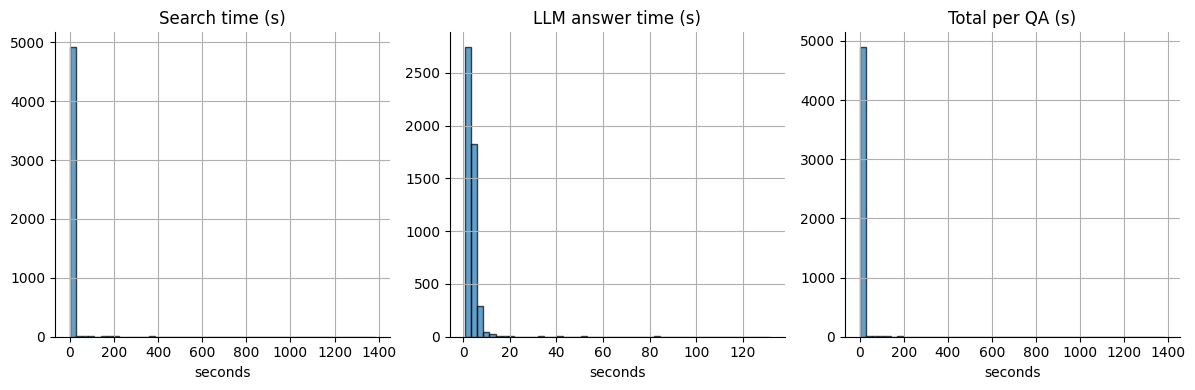

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
df["search_sec"].hist(ax=axes[0], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("Search time (s)")
axes[0].set_xlabel("seconds")
df["llm_sec"].hist(ax=axes[1], bins=50, edgecolor="black", alpha=0.7)
axes[1].set_title("LLM answer time (s)")
axes[1].set_xlabel("seconds")
df["total_sec"].hist(ax=axes[2], bins=50, edgecolor="black", alpha=0.7)
axes[2].set_title("Total per QA (s)")
axes[2].set_xlabel("seconds")
plt.tight_layout()
plt.show()

## Throughput over time

Use `ts_llm_done` to see when each QA completed; we can bin by time and count completions per minute (or per 10 minutes).

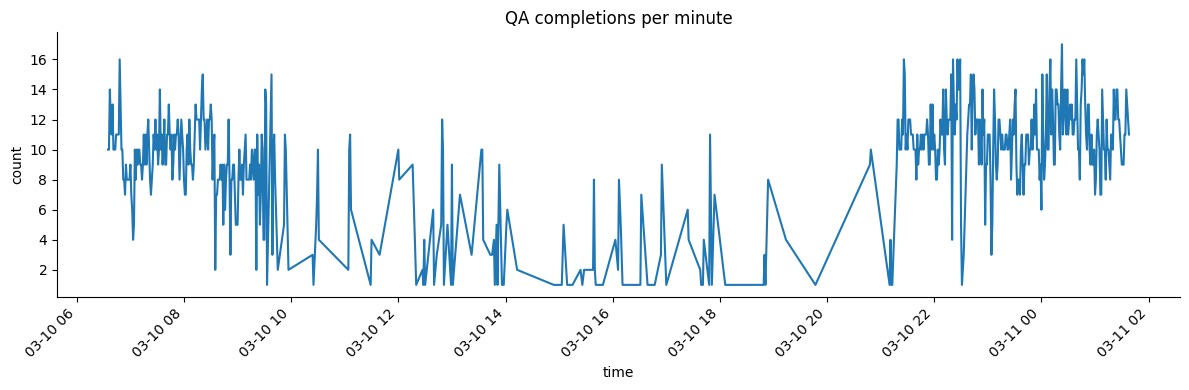

In [29]:
df["ts_llm_done_dt"] = pd.to_datetime(df["ts_llm_done"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
df = df.dropna(subset=["ts_llm_done_dt"])
df["minute"] = df["ts_llm_done_dt"].dt.floor("min")
throughput = df.groupby("minute").size()

fig, ax = plt.subplots(figsize=(12, 4))
throughput.plot(ax=ax, kind="line", title="QA completions per minute")
ax.set_ylabel("count")
ax.set_xlabel("time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Per-user (user_id) stats

Each row has `user_id` and `row`; we can aggregate latency by user.

In [30]:
per_user = df.groupby("user_id").agg(
    count=("global_qa_index", "count"),
    search_sec_mean=("search_sec", "mean"),
    llm_sec_mean=("llm_sec", "mean"),
    total_sec_mean=("total_sec", "mean"),
    num_results_mean=("num_results", "mean"),
).round(3)
per_user = per_user.sort_values("count", ascending=False)
print("Per user_id (top 15 by QA count):")
per_user.head(15)

Per user_id (top 15 by QA count):


,count,search_sec_mean,llm_sec_mean,total_sec_mean,num_results_mean
user_id,,,,,
66,43,2.426,3.819,6.244,10.0
55,41,2.015,5.398,7.412,10.0
429,40,48.830,4.500,53.330,0.0
237,38,1.974,3.311,5.284,10.0
901,37,1.589,2.241,3.830,10.0
247,36,2.103,2.608,4.711,0.0
168,36,1.747,4.233,5.981,10.0
635,35,1.754,2.200,3.954,0.0
643,35,1.857,2.549,4.406,10.0


## Retrieval: distribution of num_results

How often did search return 0 vs 10 results?

### Nice distribution plots (generation time & search time)

Histograms with mean/median lines; x-axis clipped at 99th percentile so the main bulk is visible. Outliers are noted in the corner.

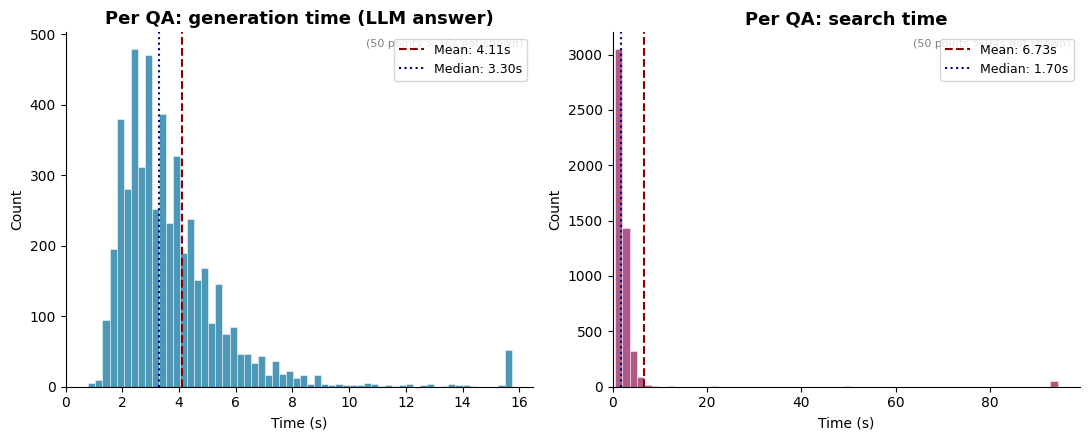

In [31]:
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

def plot_latency(series, ax, title, color, xlabel="Time (s)"):
    p99 = series.quantile(0.99)
    x = series.clip(upper=p99)
    ax.hist(x, bins=60, color=color, alpha=0.85, edgecolor="white", linewidth=0.4)
    mean_val, median_val = series.mean(), series.median()
    ax.axvline(mean_val, color="darkred", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.2f}s")
    ax.axvline(median_val, color="navy", linestyle=":", linewidth=1.5, label=f"Median: {median_val:.2f}s")
    ax.set_title(title, fontsize=13, fontweight="600")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.legend(loc="upper right", fontsize=9)
    ax.set_xlim(0, None)
    n_out = (series > p99).sum()
    if n_out > 0:
        ax.text(0.98, 0.98, f"({n_out} points > {p99:.0f}s not shown)", transform=ax.transAxes,
                ha="right", va="top", fontsize=8, color="gray")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_latency(df["llm_sec"], axes[0], "Per QA: generation time (LLM answer)", color="#2e86ab")
plot_latency(df["search_sec"], axes[1], "Per QA: search time", color="#a23b72")
plt.tight_layout()
plt.show()

num_results
0      894
1       26
7       31
10    4040
Name: count, dtype: int64


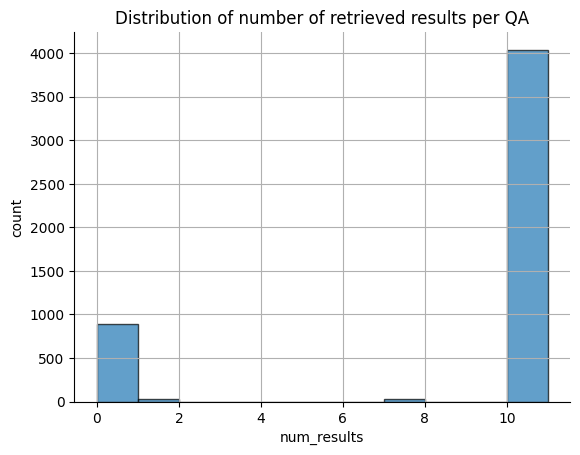

In [32]:
print(df["num_results"].value_counts().sort_index())
df["num_results"].hist(bins=range(0, int(df["num_results"].max()) + 2), edgecolor="black", alpha=0.7)
plt.title("Distribution of number of retrieved results per QA")
plt.xlabel("num_results")
plt.ylabel("count")
plt.show()

## Which log file contributed each record (after dedup)

Useful to see which run segment produced the canonical record for each global index.

In [33]:
log_contrib = df.groupby("log_file").agg(
    records_kept=("global_qa_index", "count"),
    global_min=("global_qa_index", "min"),
    global_max=("global_qa_index", "max"),
).sort_values("global_min")
print("After dedup: how many canonical records came from each log file")
log_contrib

After dedup: how many canonical records came from each log file


,records_kept,global_min,global_max
log_file,,,
flow_stage2_RUN-2_20260310_063452.log,2171,1,2180
flow_stage2_RUN-3_20260310_211756.log,681,2181,2861
flow_stage2_RUN-3_20260310_222044.log,448,2862,3309
flow_stage2_RUN-3_20260310_230543.log,1691,3310,5000


In [34]:
# Optional: export unified Stage 2 table for downstream use (e.g. joining with JSON answers)
out_path = LOG_DIR / "stage2_unified_from_logs.csv"
cols = ["global_qa_index", "user_id", "row", "search_sec", "llm_sec", "total_sec", "num_results", "ts_search_start", "ts_llm_done", "log_file"]
df[cols].to_csv(out_path, index=False)
print(f"Saved {len(df)} rows to {out_path}")

Saved 4991 rows to benchmark_logs/multi_gpt-4.1-mini_graph_2try/stage2_unified_from_logs.csv
